# MDS Central Limit Theorem Homework

### Question 1 - Experiment to sample from a normal distribution

In [1]:
import numpy as np # this package contains important numerical handling functions
from scipy import stats # this package is used for scientific and technical computing -- this is an example of importing just one part of a larger package.
import matplotlib.pyplot as plt # this package is used for creating static, animated, and interactive visualizations in Python. 
# feel free to use other packages, like seaborn, etc.

In [2]:
def sample_normal_distribution(mean, std_dev, n):
    """
    Returns the mean value observed from n samples taken from a normal distribution
    """
    samples = np.random.normal(mean, std_dev, n)
    sample_mean = np.mean(samples)
    return sample_mean

In [3]:
# Here is the specific computational experiment for a range of different n and 
# enough trials to understand the long-range behavior of sampling

n = range(1,50)
num_trials = 1000
mu = 3
std_dev = 1

sample_dict = {}
for i in n:
    means = []
    for _ in range(num_trials):
        sample_mean = sample_normal_distribution(mu, std_dev, i)
        means.append(sample_mean)
    sample_dict[i] = means

# Check this shape makes sense
print(f"Number of different n values: {len(sample_dict.keys())}")
print(f"Number of trials for each n: {len(sample_dict[1])}")


Number of different n values: 49
Number of trials for each n: 1000


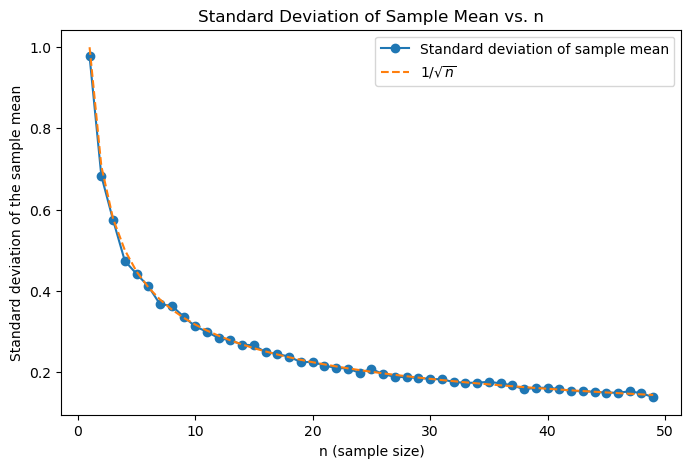

In [5]:
## Question 1A ##

# Calculate the standard deviation of the means for each value of n
n_values = list(sample_dict.keys())
sample_std_devs = [np.std(sample_dict[i]) for i in n_values]
theoretical_std_devs = [1 / np.sqrt(i) for i in n_values]

plt.figure(figsize=(8, 5))  
plt.plot(n_values, sample_std_devs, marker='o', label='Standard deviation of sample mean') # had to use Claude to make the graph more visually appealing
plt.plot(n_values, theoretical_std_devs, linestyle='--', label=r'$1/\sqrt{n}$') # "Can you give me tips of what to include to make my plots 'prettier'"
plt.xlabel('n (sample size)')
plt.ylabel('Standard deviation of the sample mean')
plt.title('Standard Deviation of Sample Mean vs. n')
plt.legend()
plt.show()

C:\Users\sbq8wb\AppData\Local\Temp\ipykernel_64452\1356815994.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=n_values)


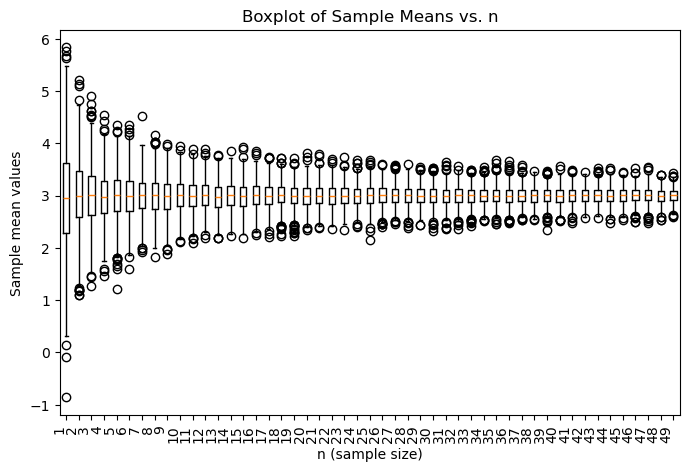

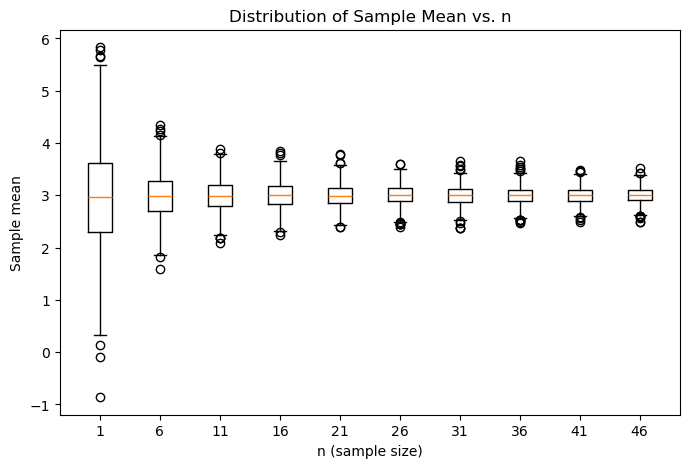

In [8]:
## Question 1b ##

data_to_plot = [sample_dict[i] for i in n_values]

plt.figure(figsize=(8,5))
plt.boxplot(data_to_plot, labels=n_values)
plt.xlabel('n (sample size)')
plt.ylabel('Sample mean values')
plt.title('Boxplot of Sample Means vs. n')
plt.xticks(rotation = 90, ha = 'right')
plt.show()

# I found that showing every n was difficult to read, so by showing 5n+1 (assuming n begins at 0) we can understand how the data set generally behaves
n_subset = n_values[::5] # take every fifth n 
data_subset = [sample_dict[i] for i in n_subset]

plt.figure(figsize=(8, 5))
plt.boxplot(data_subset, positions=n_subset, widths=2)
plt.xlabel('n (sample size)')
plt.ylabel('Sample mean')
plt.title('Distribution of Sample Mean vs. n')

plt.show()

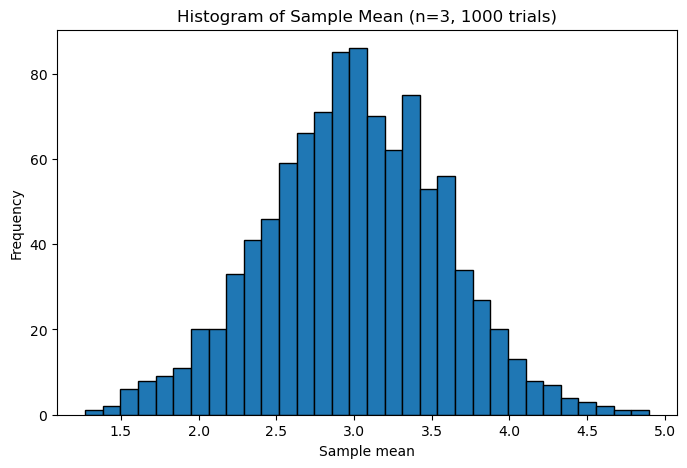

KS statistic: 0.0163
p-value: 0.9481
mean: 2.999678
sd: 0.5744
Fail to reject the null hypothesis


In [24]:
## Question 1C ##

means_n3 = np.array(sample_dict[3]) # only take data from n=3 (third position in the array)
k = np.sqrt(num_trials)
k = round(k)
plt.figure(figsize=(8, 5))
plt.hist(means_n3, bins=k, edgecolor='black')
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Mean (n=3, 1000 trials)')
plt.show()

z_scores_n3 = (means_n3 - np.mean(means_n3)) / np.std(means_n3) # calculated z score 

mean3 = np.mean(means_n3)
sd3= np.std(means_n3, ddof =1)


ks_stat, p_value = stats.kstest(z_scores_n3, 'norm') # find max. difference and p_value from z score
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"mean: {mean3:4f}")
print(f"sd: {sd3:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")


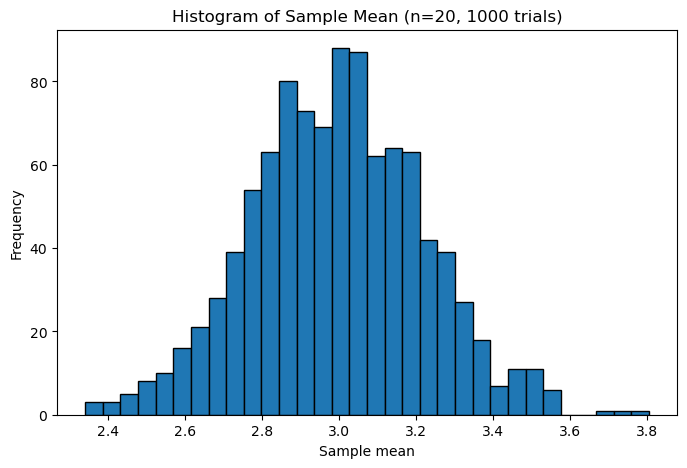

KS statistic: 0.0184
p-value: 0.8815
mean: 2.995509
sd: 0.2247
Fail to reject the null hypothesis


In [25]:
## Question 1D ##
means_n20 = np.array(sample_dict[20]) # take data only from n=20 (the twentieth position in the array)

k = np.sqrt(num_trials)
k = round(k)

plt.figure(figsize=(8, 5))
plt.hist(means_n20, bins=k, edgecolor='black')
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Mean (n=20, 1000 trials)')
plt.show()

mean20 = np.mean(means_n20)
sd20 = np.std(means_n20, ddof =1)

z_scores_n20 = (means_n20 - np.mean(means_n20)) / np.std(means_n20) # calculate z score

ks_stat, p_value = stats.kstest(z_scores_n20, 'norm') # calculate max. difference and p value from z score
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"mean: {mean20:4f}")
print(f"sd: {sd20:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

In [21]:
## Question 1E ##

means_n20 = np.array(sample_dict[20])

ks_statistic, p_value = stats.kstest(means_n20, 'norm')

mean20_nt = np.mean(means_n20)
sd20_nt = np.std(means_n20, ddof=1)


print(f"p-value: {p_value:.4f}")
print(f"mean: {mean20_nt:4f}")
print(f"sd: {sd20_nt:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

p-value: 0.0000
mean: 2.995509
sd: 0.2247
Reject the null hypothesis


In [26]:
## Question 1F ##

#Shapiro-Wilkes Test
shapiro_test3 = stats.shapiro(means_n3)

shapiro_test20 = stats.shapiro(means_n20)

print(f"Shapiro-Wilk Test for n=3:")
print(f"p-value: {shapiro_test3[1]}")

print(f"Shapiro-Wilk Test for n=20:")
print(f"p-value: {shapiro_test20[1]}")


Shapiro-Wilk Test for n=3:
p-value: 0.8445551128341653
Shapiro-Wilk Test for n=20:
p-value: 0.7565464090615358


In [27]:
## Question 2 ##

def sample_weibull_distribution(alpha, beta, n): # used the given def from above to help structure this one
    """
    Returns the mean value observed from n samples taken from a Weibull
    distribution with shape parameter alpha and scale parameter beta.
    """
    samples = stats.weibull_min.rvs(c=alpha, scale=beta, size=n)
    sample_mean = np.mean(samples)
    return sample_mean


In [48]:
w_alpha = 1
w_beta = 1
num_trials = 1000
n = range(1,50)

sample_dict_w = {}
for i in n:
    means_w = []
    for _ in range(num_trials):
        w_sample_means = sample_weibull_distribution(w_alpha, w_beta, i)
        means_w.append(w_sample_means)
    sample_dict_w[i] = means_w
# Check this shape makes sense
print(f"Number of different n values: {len(sample_dict_w.keys())}")


Number of different n values: 49


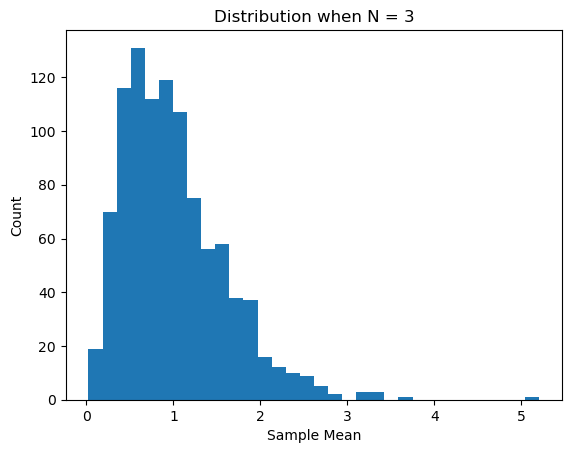

In [53]:
## Question 2B ##

k = np.sqrt(num_trials)
k = round(k)

means_n3_w = np.array(sample_dict_w[3])

# Plot the histogram of these values
plt.figure()
plt.hist(means_n3_w, bins=k)
plt.xlabel('Sample Mean')
plt.ylabel('Count')
plt.title('Distribution when N = 3')
plt.show()

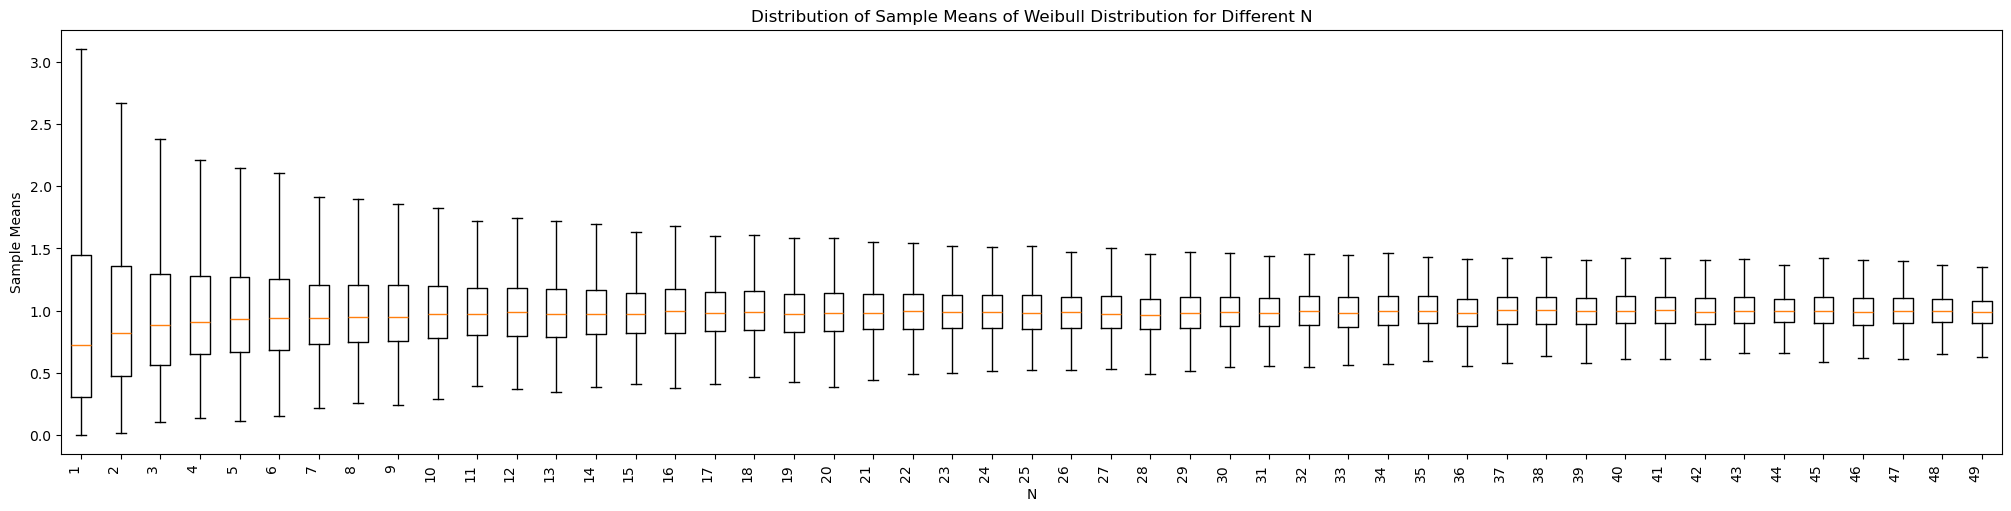

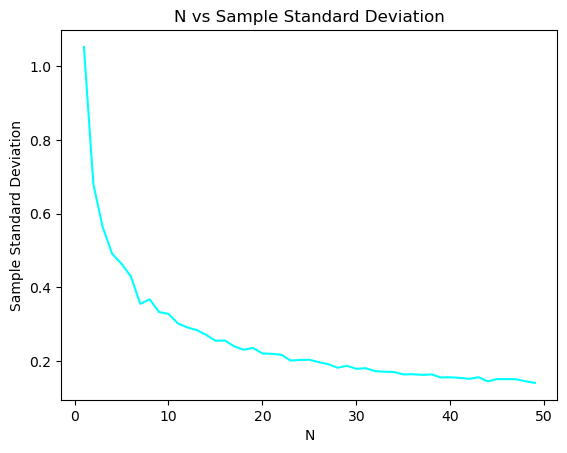

In [56]:
## Question 2C ##

fig, ax = plt.subplots(layout = 'constrained', figsize = (20, 5))
means_list_w = [sample_dict_weibull[i] for i in n]
ax.boxplot(means_list_w, showfliers=False)
ax.set_xticklabels(sample_dict_w.keys())
plt.xlabel("N")
plt.ylabel("Sample Means")
plt.title("Distribution of Sample Means of Weibull Distribution for Different N")
plt.xticks(rotation = 90, ha = 'right')
plt.show()

# Calculate SDS
sds_w = [np.std(sample_dict_weibull[i], ddof = 1 ) for i in n]

# Plot the standard deviations of the means versus n
fig, ax = plt.subplots()
ax.plot(n, sds_w, label = ' Sample Standard Deviation', color = 'cyan' )
plt.xlabel("N")
plt.ylabel("Sample Standard Deviation")
plt.title("N vs Sample Standard Deviation")
plt.show()


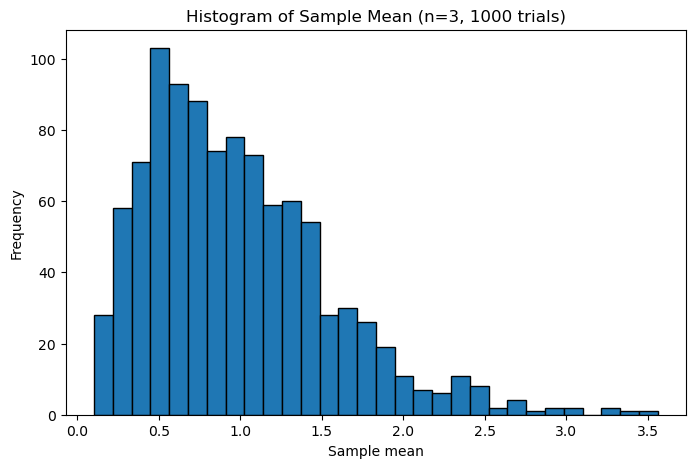

KS statistic: 0.0744
p-value: 0.0000
mean: 0.980876
sd: 0.5623
Reject the null hypothesis


In [61]:
## Question 2D ##

means_n3_weibull = np.array(sample_dict_w[3]) # pull sample means only from n=3

plt.figure(figsize=(8, 5))
plt.hist(means_n3_weibull, bins=30, edgecolor='black')
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Mean (n=3, 1000 trials)')
plt.show()

z_scores_w3 = stats.zscore(means_n3_weibull)
mean3_w = np.mean(means_n3_weibull)
sd3_w = np.std(means_n3_weibull)

ks_stat, p_value = stats.kstest(z_scores_w3, 'norm') # compute test stat and p value from z scores
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"mean: {mean3_w:4f}")
print(f"sd: {sd3_w:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

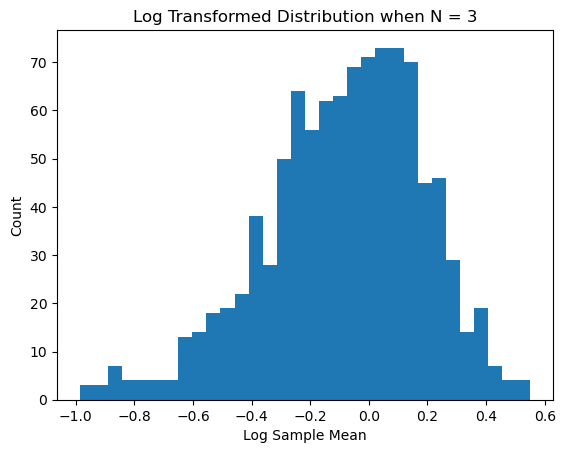

Kolmogorov-Smirnov Test Statistic (Normal): 0.04951016759094029
Kolmogorov-Smirnov Test p-value (Normal): 0.01435039415698423
Reject the null hypothesis


In [63]:
## Question 2E ##

log_means_w_3 = np.log10(means_n3_weibull)

fig, axs = plt.subplots()
axs.hist(log_means_w_3, bins=k)
plt.xlabel('Log Sample Mean')
plt.ylabel('Count')
plt.title('Log Transformed Distribution when N = 3')
plt.show()

# Test and report whether the distribution is Weibull or Normal
zscore_logw_3 = stats.zscore(log_means_w_3)
ks_statistic_norm, p_value_norm = stats.kstest(zscore_logw_3, 'norm')


print(f"Kolmogorov-Smirnov Test Statistic (Normal): {ks_statistic_norm}")
print(f"Kolmogorov-Smirnov Test p-value (Normal): {p_value_norm}")
alpha = 0.05
if p_value_norm < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

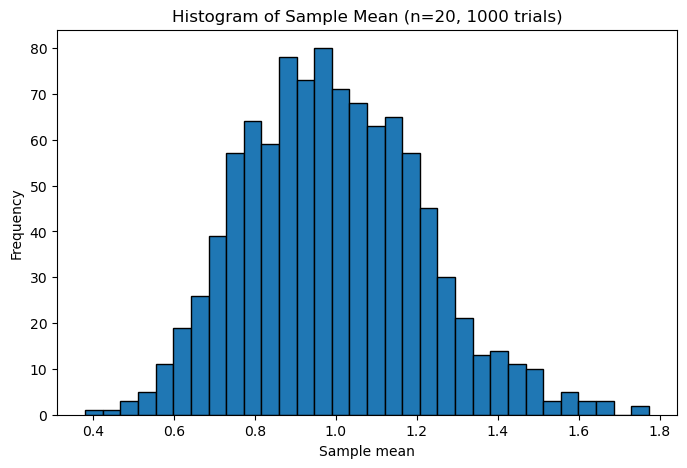

KS statistic: 0.0264
p-value: 0.4823
mean: 0.994107
sd: 0.2202
Fail to reject the null hypothesis


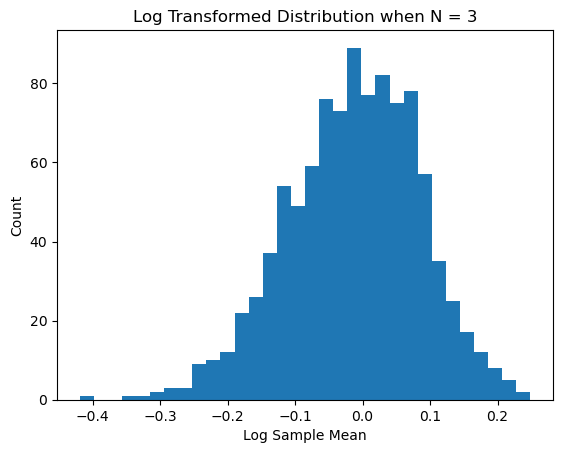

Kolmogorov-Smirnov Test Statistic (Normal): 0.030568181226582003
Kolmogorov-Smirnov Test p-value (Normal): 0.3013499228420543
Fail to reject the null hypothesis


In [65]:
## Question 2F ## 

# Repeat 2D for N = 20
means_n20_weibull = np.array(sample_dict_w[20]) # pull sample means only from n=3

plt.figure(figsize=(8, 5))
plt.hist(means_n20_weibull, bins=k, edgecolor='black')
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Mean (n=20, 1000 trials)')
plt.show()

z_scores_w20 = stats.zscore(means_n20_weibull)
mean20_w = np.mean(means_n20_weibull)
sd20_w = np.std(means_n20_weibull)

ks_stat20, p_value20 = stats.kstest(z_scores_w20, 'norm') # compute test stat and p value from z scores
print(f"KS statistic: {ks_stat20:.4f}")
print(f"p-value: {p_value20:.4f}")
print(f"mean: {mean20_w:4f}")
print(f"sd: {sd20_w:.4f}")

alpha = 0.05
if p_value20 < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

# Repeat 2E for N = 20
log_means_w_20 = np.log10(means_n20_weibull)

fig, axs = plt.subplots()
axs.hist(log_means_w_20, bins=k)
plt.xlabel('Log Sample Mean')
plt.ylabel('Count')
plt.title('Log Transformed Distribution when N = 3')
plt.show()

# Test and report whether the distribution is Weibull or Normal
zscore_logw_20 = stats.zscore(log_means_w_20)
ks_statistic_norm20, p_value_norm20 = stats.kstest(zscore_logw_20, 'norm')


print(f"Kolmogorov-Smirnov Test Statistic (Normal): {ks_statistic_norm20}")
print(f"Kolmogorov-Smirnov Test p-value (Normal): {p_value_norm20}")
alpha = 0.05
if p_value_norm20 < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Number of different n values: 49


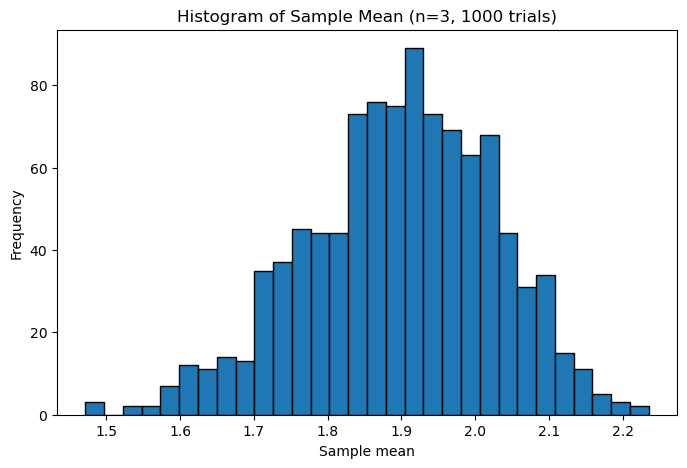

KS statistic: 0.0309
p-value: 0.2891
mean: 1.898353
sd: 0.1281
Fail to reject the null hypothesis


In [67]:
## Question 2G ## 

# Repeat 2D but A = 10 and B = 2 (n=3)

w_alpha = 10
w_beta = 2
num_trials = 1000
n = range(1,50)

sample_dict_w = {}
for i in n:
    means_w = []
    for _ in range(num_trials):
        w_sample_means = sample_weibull_distribution(w_alpha, w_beta, i)
        means_w.append(w_sample_means)
    sample_dict_w[i] = means_w
# Check this shape makes sense
print(f"Number of different n values: {len(sample_dict_w.keys())}")


means_n3_weibull = np.array(sample_dict_w[3]) # pull sample means only from n=3

plt.figure(figsize=(8, 5))
plt.hist(means_n3_weibull, bins=30, edgecolor='black')
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Mean (n=3, 1000 trials)')
plt.show()

z_scores_w3 = stats.zscore(means_n3_weibull)
mean3_w = np.mean(means_n3_weibull)
sd3_w = np.std(means_n3_weibull)

ks_stat, p_value = stats.kstest(z_scores_w3, 'norm') # compute test stat and p value from z scores
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"mean: {mean3_w:4f}")
print(f"sd: {sd3_w:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")